In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, f1_score, \
    balanced_accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

from CustomSpeachDataset import CustomSpeachDataset
from Ensemble import Ensemble

In [17]:
plt.style.use("default")

In [18]:
device = device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [19]:
MODELS_DIR = Path("checkpoints")

In [ ]:
dataset = CustomSpeachDataset(Path("preprocessed_dataset"), preload=False, device=device)

In [29]:
pd.DataFrame(dataset.LABEL_NAMES, columns=["label"])

,label
0,dog
1,cat
2,bird
3,stop
4,wow
5,up
6,down
7,go
8,happy
9,zero


In [21]:
_, test_indices = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    stratify=dataset.y.cpu(),
    random_state=42
)

test_dataset = torch.utils.data.Subset(dataset, test_indices)
test_loader = DataLoader(test_dataset, batch_size=1024)

{'lr': 0.001, 'dropout_rate': 0.3}
f1_score_weighted=0.8277
balanced_accuracy=0.8324


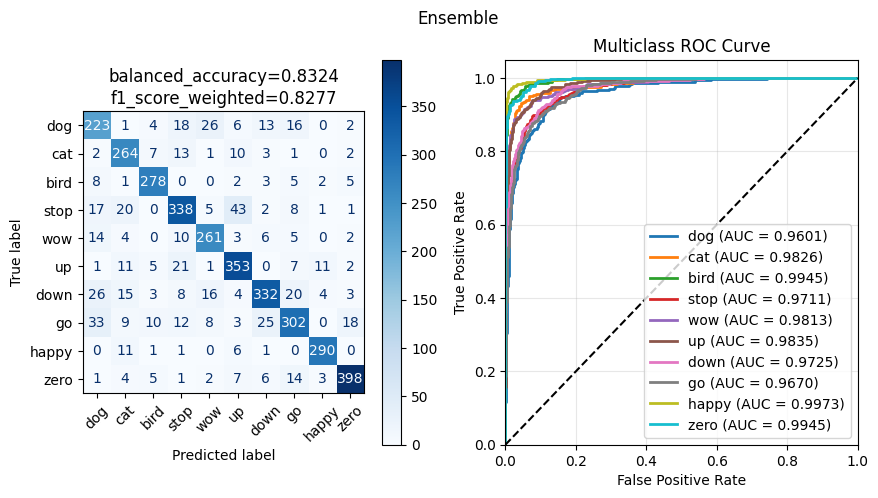

In [47]:
ensemble = Ensemble(MODELS_DIR/"training")
ensemble.to(device)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle(f"Ensemble")

probs_batches = []
y_test_batches = []
with torch.no_grad():
    for X, y in test_loader:
        y_pred = ensemble(X).cpu()
        probs_batches.append(y_pred)
        y_test_batches.append(y)

probs = np.concatenate(probs_batches)
y_test = np.concatenate(y_test_batches)
y_pred = np.argmax(probs, axis=1)

balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
f1_score_weighted = f1_score(y_test, y_pred, average='weighted')

print(ensemble.model_params)
print(f"{f1_score_weighted=:.4f}")
print(f"{balanced_accuracy=:.4f}")

classes = dataset.LABEL_NAMES

ax = axs[0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
ax.set_title(f"{balanced_accuracy=:.4f}\n{f1_score_weighted=:.4f}")

ax = axs[1]

fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = len(dataset.LABEL_NAMES)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown",
          "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

for i, color in zip(range(n_classes), colors):
    ax.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'{dataset.LABEL_NAMES[i]} (AUC = {roc_auc[i]:.4f})'
    )

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

plt.show()


In [59]:
f1_ovr = f1_score(y_test, y_pred, average=None)

pd.DataFrame({
    "label": dataset.LABEL_NAMES,
    "f1_ovr": f1_ovr,
}).sort_values(by=["f1_ovr"], ascending=False)

,label,f1_ovr
8,happy,0.933977
9,zero,0.910755
2,bird,0.901135
4,wow,0.835200
5,up,0.831567
1,cat,0.821151
6,down,0.807786
3,stop,0.788798
7,go,0.756892
0,dog,0.703470
